# COMP24112 Summative Exercise (30 Marks)
# On Linear Classification and MLP Regression

In this lab exercise, you will build linear classifiers by gradient descent for loan approval classification (14 marks) and build MLP regressors for crop production prediction (16 marks), using two given datasets. To prepare for this lab exercise, you will
* Get familiar with lecture content of Chapters 3-7.
* Get familiar with how to build a regression model by mutlilayer perceptron (MLP) using the scikit learn tutorial (https://scikit-learn.org/stable/modules/neural_networks_supervised.html#regression).
* Get familiar with basic scikit-learn tools for [data splitting](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) and [cross validation](https://scikit-learn.org/stable/modules/cross_validation.html), used for setting machine learning experiments.


You will submit a notebook file, a pdf report, and a trained model. You will be marked for implementation, design, result and analysis. Your code should be easy to read and your report should be concise (max 600 words). It is strongly recommended that you use a LaTeX editor, such as [Overleaf](https://www.overleaf.com/), to write your report. Handwritten reports will not be accepted.

Please note your notebook should take no more than 10 minutes to run on a Google Colab instance. **Marks may be dropped for inefficient and unreadable code.**


In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import time
import sklearn.model_selection
from openpyxl.styles.builtins import output

notebook_start_time = time.time()
loan_data_full = pd.read_csv("data/loan_data.csv")

# Display a sample of the original dataset, which includes both categorical and numerical features
loan_data_full.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [2]:
# Generate and display summary statistics of the dataset to check key attributes such as sample count, mean, and standard deviation of numerical features
loan_data_full.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [3]:
# Data preprocessing: Convert categorical features into one-hot encoded format
# The categorical features being encoded include: person_gender, person_education, person_home_ownership, loan_intent, and previous_loan_defaults_on_file
loan_data = pd.get_dummies(loan_data_full, columns=['person_home_ownership', 'loan_intent', 'person_education', 'previous_loan_defaults_on_file', 'person_gender'])
# Remove redundant columns to avoid multicollinearity
loan_data = loan_data.drop(columns=['person_gender_male', 'previous_loan_defaults_on_file_No'])

# Display a sample of the dataset after preprocessing
loan_data.head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,person_home_ownership_MORTGAGE,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_education_Associate,person_education_Bachelor,person_education_Doctorate,person_education_High School,person_education_Master,previous_loan_defaults_on_file_Yes,person_gender_female
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1,False,...,False,True,False,False,False,False,False,True,False,True
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,False,...,False,False,False,False,False,False,True,False,True,True
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1,True,...,True,False,False,False,False,False,True,False,False,True
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1,False,...,True,False,False,False,True,False,False,False,False,True
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1,False,...,True,False,False,False,False,False,False,True,False,False



### 1.2 Model Training and Testing (4 marks)
**On Model and Training Objective Function**: Train a binary linear classifier by minimising a hinge loss with L2 (ridge) regularisation. Specifically, given a set of $N$ training samples $\{(\mathbf{x}_i, y_i)\}_{i=1}^N$, where $\mathbf{x}_i$ is the feature vector and $y_i \in \{-1, +1\}$ is the class label for the $i$-th training sample, the training objective function to minimise is
$$O = C \sum^N_{i=1}\max\left(0, 1 - y_i \left(\mathbf{w}^T\mathbf{x}_i + w_0\right)\right) + \frac{1}{2}\mathbf{w}^T\mathbf{w}. $$
Here, $\mathbf{w}$ is a column weight vector of the linear model, $w_0$ is the bias parameter of the model, and $C$ is the regularisation hyperparameter.

**Instruction for Implementing `linear_gd_train`**: Complete the implementation of the training function `linear_gd_train` below, which trains a linear model by minimising the above training loss using gradient descent. The function should return the trained model weights and the corresponding objective function value per iteration. In addition to the training data, the function should take the regularisation hyperparameter $C$, learning rate $\eta$, and the number of iterations $N_{max}$ as arguments. A reasonably good setting of these parameters has been provided below. *Marking notes: Scikit-learn and PyTorch are NOT allowed for implementating* `linear_gd_train`*. You should avoid using* `for` *loops in your implementation of the objective function or weight update, and instead use built-in numpy operations for efficiency.*

In [4]:

def linear_gd_train(data, labels, c=0.2, n_iters=200, learning_rate=0.0001, random_state=None # Add any other arguments here if needed      
          ):
    """
    A summary of your function goes here.

    data: training data
    labels: training labels (boolean)
    c: regularisation parameter
    n_iters: number of iterations
    learning_rate: learning rate for gradient descent

    Returns an array of cost and model weights per iteration.
    """
    # Set random seed for reproducibility if using random initialisation of weights (optional)
    rng = np.random.default_rng(seed=random_state)

    # Create data, labels, and weights  
    X_tilde = data # Shape: (Samples, features
    #y.reshape(-1, 1) will turn the labels [0, 1, ,0 ...] = [[0], [1], [0] ..] from 1D to 2D column vector
    y = 2 * labels.values.astype(float).reshape(-1,1)-1 # Shape: (Samples, 1), {0,1} → {-1,1}
    # Weight initialisation: use e.g. rng.standard_normal() or all zeros
    w = rng.standard_normal(size=(X_tilde.shape[1], 1)) # Shape: (Features, 1) feature column

    # Initialise arrays to store weights and cost at each iteration
    w_all = np.zeros((n_iters, X_tilde.shape[1] + 1, 1), dtype = np.float64) # Initialise matrix with rows=iterations, columns=features and each column represent a weight
    cost_all = np.zeros(n_iters) # Loss function value
    
    #Add bias term to the data matrix where N: samples, d: features
    X_bias = np.concatenate((np.ones((X_tilde.shape[0], 1), dtype=np.float64), X_tilde), axis=1) # Shape: (N, d+1) 
    w_bias = np.concatenate((np.zeros((1, 1), dtype=np.float64), w), axis=0) # Shape: (d+1, 1)
    
    # GD update of weights
    for i in range(n_iters):
        # Cost and gradient update of the linear mode
        
        y_pred = X_bias @ w_bias # Shape: (N, 1)
        
        # Calculate hinge loss
        hinge_loss = np.maximum(0, 1 - y * y_pred) # Shape: (N, 1)
        
        cost = c * np.sum(hinge_loss) + 0.5 * np.sum(w_bias[1:]**2) # Scalar
        
        # Weight update (two cases)
        gradient = c * X_bias.T @ (-y * (hinge_loss>0).astype(float)) # Shape: (d+1, 1) Gradient
        
        gradient[1:] += w_bias[1:] # Shape: (d+1, 1), The derivative of the regularisaiton term is simply w so we add it to the gradient
        
        # Update the feature weights
        w_bias = w_bias - learning_rate * gradient
        
        # save w and cost of each iteration in w_all and cost_all
        cost_all[i] = cost # [Scalar].size() = 200
        w_all[i] = w_bias # Shape: [(N, d+1)].size() = 200  Including bias array


    # Return model parameters.
    return cost_all, w_all



def linear_predict(data, w):
    """
    A summary of your function goes here.

    data: test data
    w: model weights

    Returns the predicted labels.   
    """
    
    X_bias = np.concatenate((np.ones((data.shape[0], 1)), data), axis=1)

    # Calculate predictions
    y_pred = X_bias @ w  # Matrix multiplication
    
    return y_pred



**On Data Splitting**: Use the provided code below to split the data into training and testing sets.

In [5]:
from sklearn.preprocessing import StandardScaler

# Separate the features and target variable
binary_features = loan_data.drop(columns=['loan_status'])
binary_targets = loan_data['loan_status']

# Named _cls to keep our classification experiments distinct from regression
train_X_cls, test_X_cls, train_y_cls, test_y_cls = sklearn.model_selection.train_test_split(binary_features, binary_targets, test_size=0.15, stratify=binary_targets)

# Standardise the data
scaler = StandardScaler()

train_X_cls = scaler.fit_transform(train_X_cls)

**Instruction for Classification Experiment**: Write your code below to (1) train the model, (2) plot the training objective function value and the classification accuracy of the training set over iterations, and (3) print the classification accuracy and $F_1$ score of the testing set. Use the default setting provided in `linear_gd_train` for $C$, $\eta$ and $N_{max}$. Your plot should have axis labels and titles.

The training accuracy of the model is: 0.8956339869281046 %
[14569.9776826  12111.54202909 10085.10914825  8483.39923177
  7239.47180107  6276.49588984  5515.70862966  4915.20206655
  4452.33585848  4103.61805595  3842.64143084  3645.5408038
  3492.13433082  3369.08265778  3267.49619202  3179.74689548
  3100.33113318  3026.78630319  2957.4241791   2891.06251872
  2826.96995907  2764.76636141  2704.07887353  2644.65508123
  2586.1631446   2528.48198548  2472.04415681  2416.77955366
  2363.54477907  2312.80811585  2265.46645821  2221.71104447
  2182.58443122  2147.95621481  2117.28431412  2090.98401103
  2068.85193802  2050.99243208  2036.8504505   2025.71006122
  2016.72514777  2009.79222027  2004.20514131  1999.63740828
  1995.79543255  1992.57579472  1989.7570212   1987.34790132
  1985.20473238  1983.28739051  1981.56187607  1979.94229839
  1978.41314393  1976.98087849  1975.61411101  1974.28738146
  1972.99864034  1971.74287505  1970.50770635  1969.29407648
  1968.11694275  1966.9627

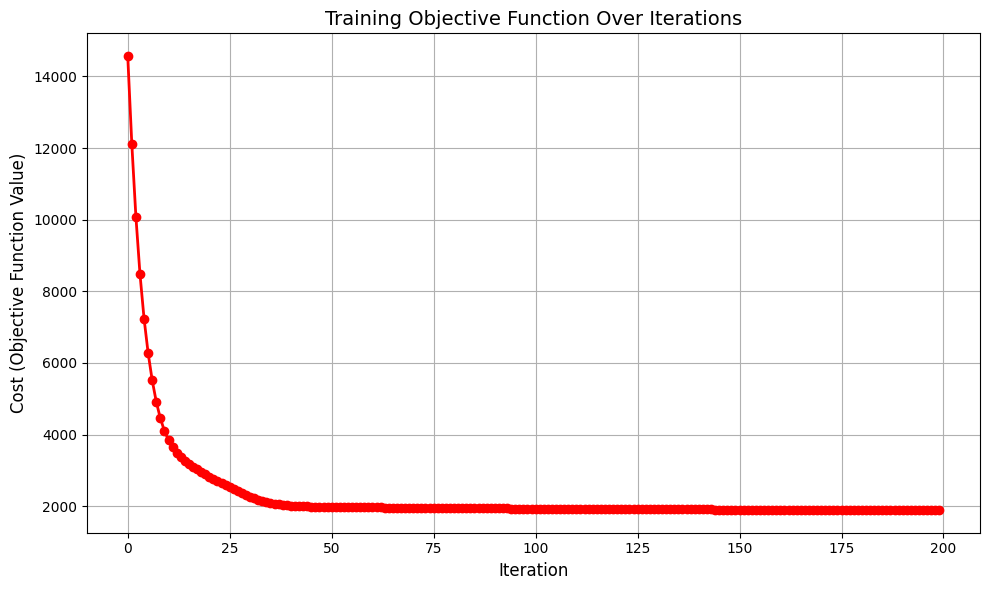

The test accuracy of the model is: 0.8952592592592593 %
The F1 score of the model is: 0.7581252138214163 %
loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64


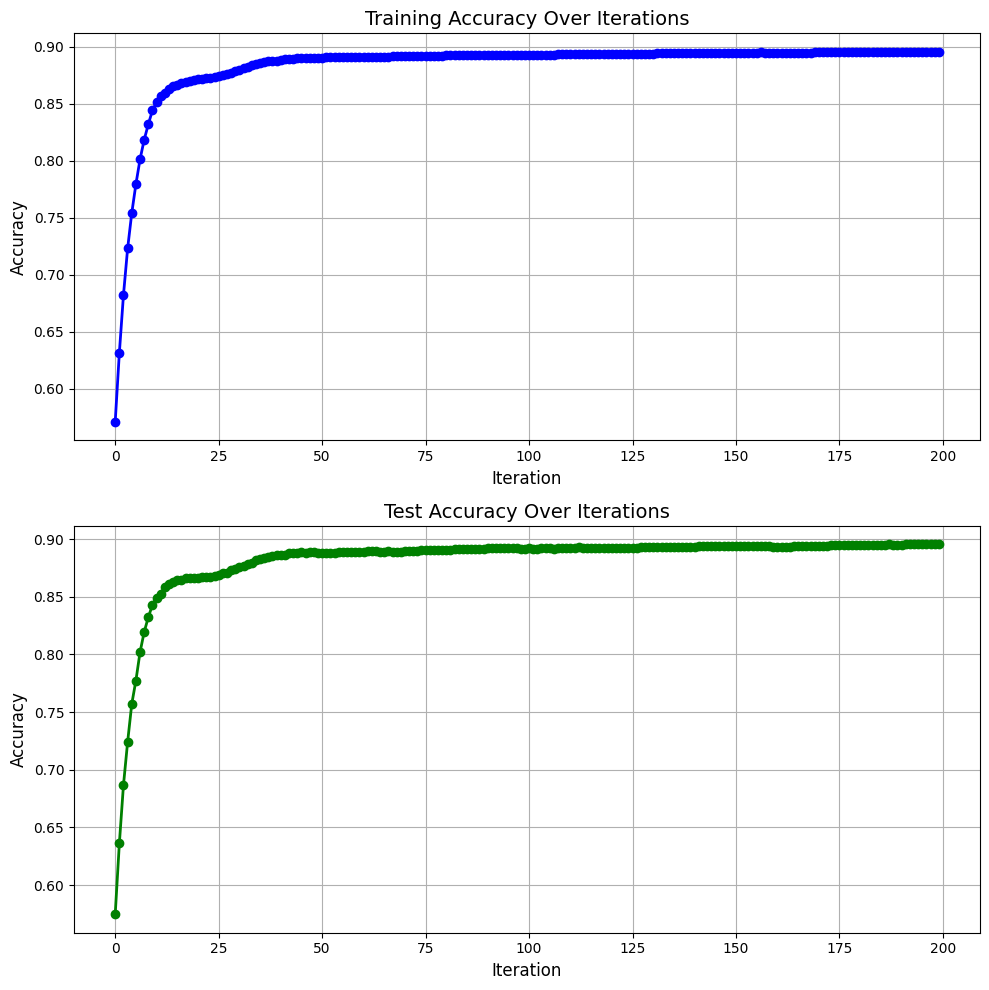

In [6]:
# Train the model
np.random.seed(42)
cost_history, weight_history = linear_gd_train(train_X_cls, train_y_cls)
training_accuracy = []
for i in range(len(cost_history)):
    y_pred = linear_predict(train_X_cls, weight_history[i])
    training_accuracy.append(np.mean((y_pred > 0) == train_y_cls.values.reshape(-1,1))) # mean accuracy of the training set compares boolean outputs

# Plot accuracy and cost per iteration on training set
print("The training accuracy of the model is: " + str(training_accuracy[-1]) + " %")
#print(train_y_cls.value_counts(normalize=True))

print(cost_history)
print(training_accuracy)

plt.figure(figsize=(10, 6))
plt.plot(range(len(cost_history)), cost_history, marker='o', linewidth=2, color='red')
plt.title("Training Objective Function Over Iterations", fontsize=14)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Cost (Objective Function Value)", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# Standardise the test dataset
test_X_cls = scaler.transform(test_X_cls)


test_accuracy = []
for i in range(len(cost_history)):
    y_pred = linear_predict(test_X_cls, weight_history[i])
    test_accuracy.append(np.mean((y_pred > 0) == test_y_cls.values.reshape(-1,1))) # mean accuracy of the training set compares boolean outputs
#print(test_accuracy)
print("The test accuracy of the model is: " + str(test_accuracy[-1]) + " %")
#print(train_y_cls.value_counts(normalize=True))

precision_test = np.sum((y_pred > 0) & (test_y_cls.values.reshape(-1,1) == 1)) / np.sum(y_pred > 0)
recall_test = np.sum((y_pred > 0) & (test_y_cls.values.reshape(-1,1) == 1)) / np.sum(test_y_cls.values.reshape(-1,1) == 1)
F1_score = 2 * (precision_test * recall_test) / (precision_test + recall_test)
print("The F1 score of the model is: " + str(F1_score) + " %")

# Predict on test set, report accuracy and f1 score
print(train_y_cls.value_counts(normalize=True))

plt.figure(figsize=(10, 10))

# Plot training accuracy on the first subplot (top)
plt.subplot(2, 1, 1)
plt.plot(range(len(training_accuracy)), training_accuracy, marker='o', linewidth=2, color='blue')
plt.title("Training Accuracy Over Iterations", fontsize=14)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(True)
plt.tick_params(axis='both', which='major', labelsize=10)

# Plot test accuracy on the second subplot (bottom)
plt.subplot(2, 1, 2)
plt.plot(range(len(test_accuracy)), test_accuracy, marker='o', linewidth=2, color='green')
plt.title("Test Accuracy Over Iterations", fontsize=14)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(True)
plt.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
plt.show()



#### 1.3 Learning Rate Analysis (4 marks)
The learning rate $\eta$ (Greek letter "eta") is a key parameter that affects the model training and performance. Design an appropriate experiment to demonstrate the effect of $\eta$ on model training, and on the model performance during testing.

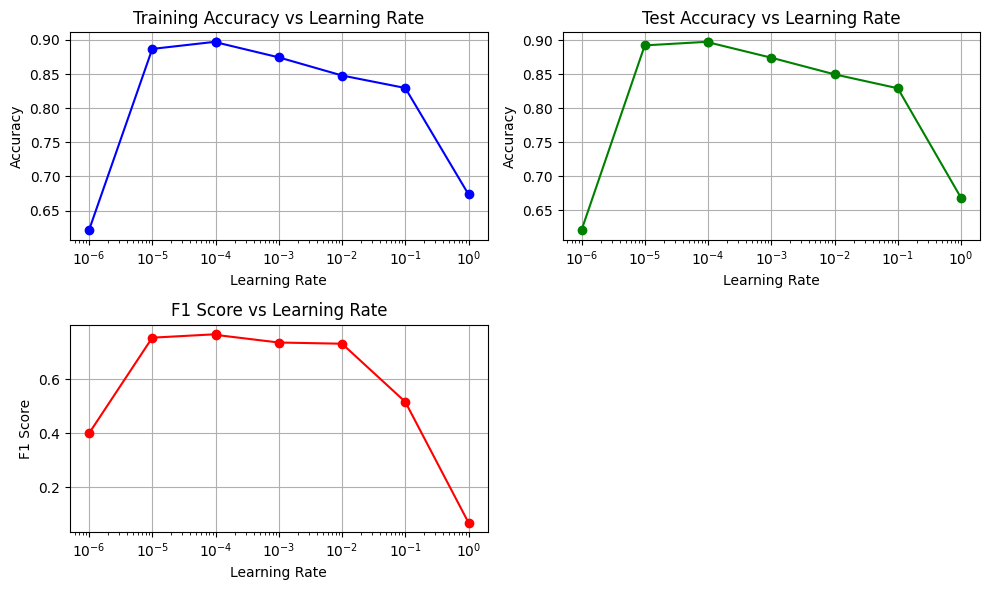

In [7]:
# Your code here# Define a list of learning rates to test
learning_rates = [0.000001, 0.00001, 0.0001, 0.0001, 0.001, 0.01, 0.1, 1]

# Initialize lists to store results
train_accuracies = []
test_accuracies = []
f1_scores = []

# Loop through each learning rate
for eta in learning_rates:  
    # Train the model with the current learning rate
    cost_history, weight_history = linear_gd_train(train_X_cls, train_y_cls, learning_rate=eta)
    
    # Compute training accuracy at the final iteration
    final_train_accuracy = np.mean((linear_predict(train_X_cls, weight_history[-1]) > 0) == train_y_cls.values.reshape(-1, 1))
    train_accuracies.append(final_train_accuracy)
    
    # Compute test accuracy at the final iteration
    final_test_accuracy = np.mean((linear_predict(test_X_cls, weight_history[-1]) > 0) == test_y_cls.values.reshape(-1, 1))
    test_accuracies.append(final_test_accuracy)
    
    # Compute F1 score on the test set
    y_pred = linear_predict(test_X_cls, weight_history[-1])
    precision_test = np.sum((y_pred > 0) & (test_y_cls.values.reshape(-1, 1) == 1)) / np.sum(y_pred > 0)
    recall_test = np.sum((y_pred > 0) & (test_y_cls.values.reshape(-1, 1) == 1)) / np.sum(test_y_cls.values.reshape(-1, 1) == 1)
    f1 = 2 * (precision_test * recall_test) / (precision_test + recall_test)
    f1_scores.append(f1)
    #print(f"Final training accuracy with {eta} learning rate: {final_train_accuracy:.4f}")
    #print(f"Final test accuracy with {eta} learing rate: {final_test_accuracy:.4f}")
    
    

# Plot the results
plt.figure(figsize=(10, 6))

# Plot training accuracy for each learning rate
plt.subplot(2, 2, 1)
plt.plot(learning_rates, train_accuracies, marker='o', color='blue', label='Training Accuracy')
plt.title('Training Accuracy vs Learning Rate')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.xscale('log')
plt.grid(True)

# Plot test accuracy for each learning rate
plt.subplot(2, 2, 2)
plt.plot(learning_rates, test_accuracies, marker='o', color='green', label='Test Accuracy')
plt.title('Test Accuracy vs Learning Rate')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.xscale('log')
plt.grid(True)

# Plot F1 score for each learning rate
plt.subplot(2, 2, 3)
plt.plot(learning_rates, f1_scores, marker='o', color='red', label='F1 Score')
plt.title('F1 Score vs Learning Rate')
plt.xlabel('Learning Rate')
plt.ylabel('F1 Score')
plt.xscale('log')
plt.grid(True)

# Show all plots
plt.tight_layout()
plt.show()


### 1.4 Report (6 Marks)
1. Summarize (1) your process of constructing the loss function and computing its gradient used by `linear_gd_train`, (2) how your Python implementation minimizes this function, and (3) key insights learned from the task. (*3 marks*)
2. Draw conclusions about your model behaviour and data from your plot produced in Section 1.2 based on classification accuracies of your training and testing sets? (*1 mark*)
3. Discuss the effect of η on model training and on testing performance, based on your observations obtained in Section 1.3. (*2 marks*)

## 2. Soybean Production Prediction by MLP (16 marks)
###  2.1 Dataset and Experiment Preparation

**On Dataset**: The provided "Soybean Agricultural Dataset" contains agricultural parameters related to soybean plant growth and production. It includes 52,678 instances with 13 features, covering plant characteristics, environmental conditions, and treatment factors, such as genotype, salicylic acid treatment, water stress, plant height, number of pods, chlorophyll content, etc. You will build a regression model by MLP to predict the soybean production, which reflects the crop yield under different experimental conditions.

**On Data Pre-processing**: This dataset also needs pre-processing. Example code on conducting one-hot encoding to convert string features to numerical values is provided below. Further pre-processing techniques are provided by Scikit-Learn data pre-processing tools (https://scikit-learn.org/stable/modules/preprocessing.html), which you will use later.

In [8]:
from sklearn.preprocessing import OneHotEncoder

# Read data
soybean_data_full = pd.read_csv("data/soybean_data.csv")

# Display a sample of the original dataset
soybean_data_full.head()

,Parameters,Random,Plant Height (PH),Number of Pods (NP),Biological Weight (BW),Sugars (Su),Relative Water Content in Leaves (RWCL),ChlorophyllA663,Chlorophyllb649,Protein Percentage (PPE),Weight of 300 Seeds (W3S),Leaf Area Index (LAI),Seed Yield per Unit Area (SYUA),Number of Seeds per Pod (NSP),Protein Content (PCO)
0,C1S1G5,R1,50.5,130.3,111.0,0.433,0.732,1.4,3.1,33.2,33.6,0.08,5567.4,1.86,0.82
1,C2S3G4,R1,44.5,132.0,80.0,0.334,0.674,7.1,2.2,38.5,34.4,0.09,2245.5,1.87,0.13
2,C2S1G6,R1,52.2,150.0,83.0,0.490,0.677,1.8,1.3,33.6,35.2,0.07,4326.7,2.04,0.15
3,C1S1G1,R1,50.5,140.8,66.0,0.163,0.745,1.1,3.0,33.5,52.3,0.09,6214.5,2.20,0.14
4,C2S2G6,R2,52.0,136.0,62.0,0.265,0.633,4.3,1.2,33.5,44.4,0.07,3985.2,2.06,0.30


In [9]:
# Get and display all unique values from the 'Parameters' column to identify distinct experimental conditions
soybean_data_full['Parameters'].unique()

# NOTE: The 'Parameters' column is a string encoding experimental conditions.
# We need to extract numerical values from this string and create separate columns for each parameter.
# Then, we will apply one-hot encoding to categorical variables to prepare the data for machine learning models.
# G: Refers to the genotype of soybean, consisting of six different genotypes.
# C: Represents salicylic acid, which has two levels (250 mg and 450 mg), along with a third level as a standard control.
# S: Indicates water stress, which includes two levels:
#       - Water stress at 5% of field capacity.
#       - Water stress at 70% of field capacity.

array(['C1S1G5', 'C2S3G4', 'C2S1G6', 'C1S1G1', 'C2S2G6', 'C1S1G6',
       'C1S3G5', 'C2S2G4', 'C2S3G1', 'C1S1G2', 'C1S3G4', 'C2S3G3',
       'C2S1G2', 'C1S3G1', 'C2S2G5', 'C2S2G1', 'C1S3G2', 'C2S1G1',
       'C2S3G2', 'C1S2G1', 'C2S1G3', 'C1S2G4', 'C1S2G6', 'C1S1G4',
       'C2S2G2', 'C1S1G3', 'C2S3G5', 'C1S2G3', 'C2S1G4', 'C2S1G5',
       'C2S3G6', 'C1S2G2', 'C1S3G6', 'C1S3G3', 'C1S2G5'], dtype=object)

In [10]:
# Extract the individual parameters from the 'parameters' column
soybean_data_processed = soybean_data_full.copy()
# Extract the genotype and one-hot encode it
encoder = OneHotEncoder()
genotypes = encoder.fit_transform(soybean_data_full['Parameters'].str.extract(r'G(\d)')).toarray()
soybean_data_processed = pd.concat([soybean_data_processed, pd.DataFrame(genotypes, columns=[f'G{i}' for i in range(1, 7)])], axis=1)

# Extract the salicylic acid treatment and encode it as 0, 250 mg, or 450 mg
# 1 = 250 mg, 2 = 450 mg, 3 = control
salicylic_acid = soybean_data_full['Parameters'].str.extract(r'C(\d+)').astype(float)
salicylic_acid = salicylic_acid.replace({1: 250, 2: 450, 3: 0})
soybean_data_processed['Salicylic acid (mg)'] = salicylic_acid

# Extract the water stress treatment and encode it as .05 or .7 of field capacity
water_stress = soybean_data_full['Parameters'].str.extract(r'S(\d)').astype(float)
water_stress = water_stress.replace({1: .05, 2: .7})
soybean_data_processed['Water Stress (pct field capacity)'] = water_stress

# Drop the original 'Parameters' column as well as 'Random' column
soybean_data_processed.drop(columns=['Parameters', 'Random '], inplace=True)

# Display a sample of the dataset after preprocessing
soybean_data_processed.head()

,Plant Height (PH),Number of Pods (NP),Biological Weight (BW),Sugars (Su),Relative Water Content in Leaves (RWCL),ChlorophyllA663,Chlorophyllb649,Protein Percentage (PPE),Weight of 300 Seeds (W3S),Leaf Area Index (LAI),...,Number of Seeds per Pod (NSP),Protein Content (PCO),G1,G2,G3,G4,G5,G6,Salicylic acid (mg),Water Stress (pct field capacity)
0,50.5,130.3,111.0,0.433,0.732,1.4,3.1,33.2,33.6,0.08,...,1.86,0.82,0.0,0.0,0.0,0.0,1.0,0.0,250.0,0.05
1,44.5,132.0,80.0,0.334,0.674,7.1,2.2,38.5,34.4,0.09,...,1.87,0.13,0.0,0.0,0.0,1.0,0.0,0.0,450.0,3.00
2,52.2,150.0,83.0,0.490,0.677,1.8,1.3,33.6,35.2,0.07,...,2.04,0.15,0.0,0.0,0.0,0.0,0.0,1.0,450.0,0.05
3,50.5,140.8,66.0,0.163,0.745,1.1,3.0,33.5,52.3,0.09,...,2.20,0.14,1.0,0.0,0.0,0.0,0.0,0.0,250.0,0.05
4,52.0,136.0,62.0,0.265,0.633,4.3,1.2,33.5,44.4,0.07,...,2.06,0.30,0.0,0.0,0.0,0.0,0.0,1.0,450.0,0.70


In [11]:
# Generate and display summary statistics of the dataset to check key attributes such as sample count, mean, and standard deviation of numerical features
soybean_data_full.describe()

,Plant Height (PH),Number of Pods (NP),Biological Weight (BW),Sugars (Su),Relative Water Content in Leaves (RWCL),ChlorophyllA663,Chlorophyllb649,Protein Percentage (PPE),Weight of 300 Seeds (W3S),Leaf Area Index (LAI),Seed Yield per Unit Area (SYUA),Number of Seeds per Pod (NSP),Protein Content (PCO)
count,52678.000000,52678.000000,52678.000000,52678.000000,52678.000000,52678.000000,52678.000000,52678.000000,52678.000000,52678.000000,52678.000000,52678.000000,52678.000000
mean,49.962588,144.938631,114.555298,0.477444,0.673589,3.937433,2.399918,36.039840,35.342259,0.072110,4388.373900,2.020035,0.507945
std,3.052511,19.984197,48.927013,0.236289,0.084562,2.844534,1.189726,2.417536,4.989765,0.022296,1251.716467,0.246010,0.287692
min,40.400000,75.000000,32.000000,0.161000,0.434000,1.000000,1.100000,31.100000,26.400000,0.020000,2127.500000,1.400000,0.120000
25%,49.200000,130.400000,80.000000,0.294250,0.633000,1.500000,1.300000,33.600000,32.200000,0.050000,3352.200000,1.850000,0.330000
50%,50.300000,147.000000,102.000000,0.463000,0.677000,2.400000,2.200000,36.600000,34.500000,0.080000,4300.700000,2.050000,0.480000
75%,52.000000,158.000000,132.750000,0.612000,0.723000,6.700000,3.100000,38.000000,37.200000,0.090000,5233.500000,2.200000,0.600000
max,55.700000,218.000000,236.000000,1.115000,0.875000,10.200000,7.800000,39.900000,53.900000,0.100000,7841.500000,2.600000,1.800000



### 2.2 MLP Model Selection (4 marks)
This exercise focuses on the practical usage and implementation of MLPs. Key hyper-parameters that can affect the MLP performance include model architecture, activation function, and the number of training iterations.

**Instruction on MLP Model Options**: You should experiment with the following model options.

* *MLP architectures* including two single-hidden-layer MLPs, one with 3 hidden neurons (small) and another with 100 hidden neurons (large), and two two-hidden-layer MLPs, one with (3,3) neurons (small) and another with (100,100) neurons (large).
* *Activation functions* including the logistic and ReLU activations.
* *Numbers of training iterations* including three different iteration numbers.

Model variations resulted from the above configurations are defined in the 'param_grid' below. All other hyperparameters follow Scikit-Learn’s default settings.


In [12]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV

'''
param_grid = [
    {
        'hidden_layer_sizes': [(3,), (100,), (3, 3), (100, 100)],
        'activation': ['relu', 'logistic'],
        'max_iter': [50, 200, 500]
    },
]
'''

# Using smaller grid in case of run time issues (Full grid in markdown at the end of model code below)
param_grid = [
    {
        'hidden_layer_sizes': [(3,), (100, 100)],
        'activation': ['relu'],
        'max_iter': [50]
    },
]



Split the dataset into the training and testing sets. 

In [13]:
# Define regression target and features, perform train-test split
target_col = 'Seed Yield per Unit Area (SYUA)'
regression_targets = soybean_data_processed[target_col].to_numpy()
soybean_data = soybean_data_processed.drop(columns=[target_col])
regression_data = soybean_data.to_numpy()
train_X_regr, test_X_regr, train_y_regr, test_y_regr = sklearn.model_selection.train_test_split(regression_data, regression_targets, test_size=0.15)

**Instruction for Regression Experiment**: Write your code below to (1) preprocess the data by standardisation (or any other pre-processing technique that you see fit), and (2) perform model selection, train and test your MLP regressors. Use the provided training set for model selection by cross-validation, and use mean squared error (MSE) as the model selection performance metric. You can use the scikit-learn module [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html#grid-search) to conduct grid search. Print the cross-validation MSE with standard deviation for the selected model. Re-train the selected model using the whole training set, and print its MSE and $R^2$ score for the testing set.

**Marking Note:** This section can often take a long time to run when a large number of models are being trained. If you are concerned about the runtime when submitting your notebook, please copy the output of the entire grid search into a markdown cell so that we can see the results. Then, re-define the param_grid so that only two models are trained. This will allow us to see that your code works without having to wait for the entire grid search to complete during marking.

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

import time
start = time.time()

'''
There is 24 possible combinations of the parameters in param_grid as we have 4x2x3=24 
We are using 5 fold cross-validation, so the total number of models to be trained is 24x5=120
'''
# Pre-process data
scalar = StandardScaler()
train_X_regr_standarised = scalar.fit_transform(train_X_regr) # Standardise the training data
test_X_regr_standarised = scalar.transform(test_X_regr) # Standardise the test data

# Define MLP model
#mlp = MLPRegressor(random_state=42, early_stopping=True, solver='adam')

mlp = MLPRegressor(
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,  # Use 10% of training data for validation
    n_iter_no_change=10,      # Stop after 10 iterations with no improvement
    solver='adam',            # Adam optimizer is typically faster than the default
    batch_size='auto',        # Let sklearn optimize batch size
    learning_rate_init=0.001  # Default learning rate for Adam
)

# Initialise and fit the grid search
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='neg_mean_squared_error', verbose=3, n_jobs=-1)
grid_search.fit(train_X_regr_standarised, train_y_regr)


results_df = pd.DataFrame(grid_search.cv_results_)

# Select the useful columns (TO VIEW RESULTS OF FULL GRID PROPERLY PRESS MARKDOWN CELL BELOW AS VIEWING CELL AND RUNNING IT HAS A WEIRD FORMAT)
important_cols = [
    'mean_test_score',
    'std_test_score',
    'rank_test_score',
    'param_activation',
    'param_hidden_layer_sizes',
    'param_max_iter'
]
# Sort by best score
results_df = results_df.sort_values(by='rank_test_score')
# Display only the important columns
print(results_df[important_cols].to_string(index=False))

# Report the best parameters and the CV results
print("Best parameters found in the training set:")
print(grid_search.best_params_)
print(f"Mean MSE: {-grid_search.best_score_:.4f}")
print(f"Standard deviation of MSE: {grid_search.cv_results_['std_test_score'][grid_search.best_index_]:.4f}")

# Report model performance with best parameters
best_mlp = grid_search.best_estimator_
test_predictions = best_mlp.predict(test_X_regr_standarised)
test_mse = mean_squared_error(test_y_regr, test_predictions)
test_r2 = r2_score(test_y_regr, test_predictions)

print("\nPerformance on the testing set:")
print(f"Test MSE: {test_mse}")
print(f"Test R^2: {test_r2}")

end = time.time()
print(f"\nTotal training time: {end - start:.2f} seconds")



Fitting 5 folds for each of 2 candidates, totalling 10 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (

[CV 3/5] END activation=relu, hidden_layer_sizes=(3,), max_iter=50;, score=-18389285.997 total time=   0.7s
[CV 5/5] END activation=relu, hidden_layer_sizes=(3,), max_iter=50;, score=-18549596.216 total time=   0.7s
[CV 4/5] END activation=relu, hidden_layer_sizes=(3,), max_iter=50;, score=-18437448.612 total time=   0.7s
[CV 2/5] END activation=relu, hidden_layer_sizes=(3,), max_iter=50;, score=-18389922.998 total time=   0.7s
[CV 1/5] END activation=relu, hidden_layer_sizes=(3,), max_iter=50;, score=-18623371.680 total time=   0.7s
[CV 2/5] END activation=relu, hidden_layer_sizes=(100, 100), max_iter=50;, score=-28.036 total time=   2.5s
[CV 5/5] END activation=relu, hidden_layer_sizes=(100, 100), max_iter=50;, score=-39.456 total time=   2.5s
[CV 3/5] END activation=relu, hidden_layer_sizes=(100, 100), max_iter=50;, score=-19.833 total time=   2.4s
[CV 4/5] END activation=relu, hidden_layer_sizes=(100, 100), max_iter=50;, score=-26.503 total time=   2.5s
[CV 1/5] END activation=relu

| mean_test_score | std_test_score | rank_test_score | param_activation | param_hidden_layer_sizes | param_max_iter |
|----------------:|---------------:|----------------:|------------------|---------------------------|----------------|
| -2.554521e+01   |     8.589923   |               1 | relu             | (100, 100)                |            200 |
| -2.554521e+01   |     8.589923   |               1 | relu             | (100, 100)                |            500 |
| -2.554521e+01   |     8.589923   |               1 | relu             | (100, 100)                |             50 |
| -2.279779e+03   |   379.428552   |               4 | relu             | (100,)                    |            500 |
| -2.279779e+03   |   379.428552   |               4 | relu             | (100,)                    |            200 |
| -1.131770e+04   | 14233.441013   |               6 | logistic         | (100, 100)                |            500 |
| -8.831170e+04   |  2692.779834   |               7 | relu             | (100,)                    |             50 |
| -9.198497e+04   |  5988.786879   |               8 | logistic         | (100,)                    |            500 |
| -2.101278e+05   | 11374.459873   |               9 | relu             | (3, 3)                    |            500 |
| -2.105603e+05   | 11193.263806   |              10 | relu             | (3, 3)                    |            200 |
| -1.056978e+06   | 24622.490743   |              11 | relu             | (3, 3)                    |             50 |
| -2.918348e+06   | 33803.967913   |              12 | logistic         | (100,)                    |            200 |
| -3.055118e+06   | 34654.280041   |              13 | logistic         | (100, 100)                |            200 |
| -3.101128e+06   | 68294.325283   |              14 | relu             | (3,)                      |            500 |
| -8.923521e+06   |112901.640278   |              15 | relu             | (3,)                      |            200 |
| -1.413765e+07   | 74469.358716   |              16 | logistic         | (100,)                    |             50 |
| -1.437595e+07   | 74966.058705   |              17 | logistic         | (100, 100)                |             50 |
| -1.806061e+07   | 84195.540054   |              18 | logistic         | (3, 3)                    |            500 |
| -1.806554e+07   | 84193.091151   |              19 | logistic         | (3,)                      |            500 |
| -1.847793e+07   | 93307.087838   |              20 | relu             | (3,)                      |             50 |
| -1.967550e+07   | 87839.925511   |              21 | logistic         | (3, 3)                    |            200 |
| -1.968068e+07   | 87833.369804   |              22 | logistic         | (3,)                      |            200 |
| -2.051129e+07   | 89665.048952   |              23 | logistic         | (3, 3)                    |             50 |
| -2.051703e+07   | 89656.291984   |              24 | logistic         | (3,)                      |             50 |

**Best parameters found on the training set:**  
`{'activation': 'relu', 'hidden_layer_sizes': (100, 100), 'max_iter': 50}`

**Mean MSE:** 25.5452  
**Standard deviation of MSE:** 8.5899  

**Performance on the testing set:**  
**Test MSE:** 24.3468  
**Test R²:** 0.99998  

**Total training time:** 354.08 seconds


### 2.3 Feature Importance Testing (4 Marks)

In real-world regression application, the accuracy of the predicted output depends on multiple input features, but not all features contribute equally. Often, some features play a significant role, while some have a minor impact on the prediction. It is useful to identify feature importance for a prediction task. Gradient Boosting is a technique for such purpose, based on which scikit-learn provides a tool [GradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html). Using this tool, we provide you the function `feature_importance_score_cal` to generate feature importance scores.  

In [15]:
# Experiment: generate importance scores using Gradient Boosting Methods
# Note: parameters have not been tuned

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance

def feature_importance_score_cal(train_X, train_y, test_X, test_y, feature_names):
    #### Train the GradientBoostingRegressor
    params = {
        'n_estimators': 400,
        'learning_rate': 0.1,
        'max_depth': 5,
        'subsample': 0.7,
    }
    gbr = GradientBoostingRegressor(**params, random_state=42)
    # fit on training data, apply to test data
    gbr.fit(train_X, train_y)
    test_mse = mean_squared_error(test_y, gbr.predict(test_X))
    test_r2 = gbr.score(test_X, test_y)
    print(f"Gradient boosting regressor on full test set gives MSE: {test_mse:.4f} and R^2 score: {test_r2:.4f}")
    feature_importance_score = gbr.feature_importances_

    sorted_idx = np.argsort(feature_importance_score)
    pos = np.arange(sorted_idx.shape[0]) + 0.5
    fig = plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.barh(pos, feature_importance_score[sorted_idx], align="center")
    plt.yticks(pos, np.array(feature_names)[sorted_idx])
    plt.title("Feature Importance (MDI)")

    ## Box plot showing the variance of feature importance scores
    result = permutation_importance(
        gbr, test_X, test_y, n_repeats=10, random_state=42, n_jobs=2
    )
    sorted_idx = result.importances_mean.argsort()
    plt.subplot(1, 2, 2)
    plt.boxplot(
        result.importances[sorted_idx].T,
        vert=False,
        labels=np.array(feature_names)[sorted_idx], # newer versions of matplotlib may use tick_labels as kwarg instead
    )
    plt.title("Permutation Importance (test set)")
    fig.tight_layout()
    plt.show()
    return feature_importance_score

# Some debugging for feature importance selection later
average_syua = soybean_data_processed['Seed Yield per Unit Area (SYUA)'].mean()

print(f"The average Seed Yield per Unit Area (SYUA) is: {average_syua:.2f}")




The average Seed Yield per Unit Area (SYUA) is: 4388.37


**Instruction on Experiment**: Design an experiment and write your code below to (1) select important features using `feature_importance_score_cal` and (2) validate the importance of the features in the dataset. **Hint**: If five features are identified as significantly more important than the others, will a good prediction accuracy be obtained by using only these five features, e.g., no significant accuracy drop as compared to using the full feature set? You may wish to read further on [feature selection](https://scikit-learn.org/stable/modules/feature_selection.html) and [Permutation Importance vs Random Forest Feature Importance (MDI)](https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance.html) before approaching this section.

Gradient boosting regressor on full test set gives MSE: 0.0000 and R^2 score: 1.0000


/var/folders/cm/0z_562752_vc_t2n90xrcxrh0000gn/T/ipykernel_26250/1602388626.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


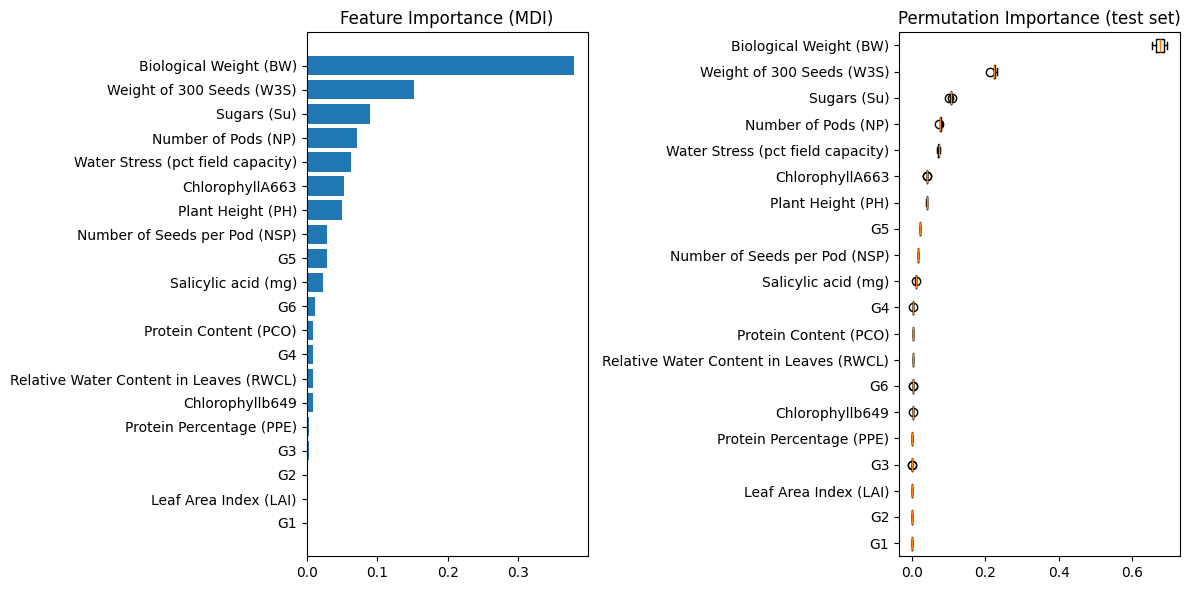


Performance of best_mlp on all features (for comparison):
Test MSE (all features): 24.346807301696895
Test R^2 (all features): 0.9999845098261263


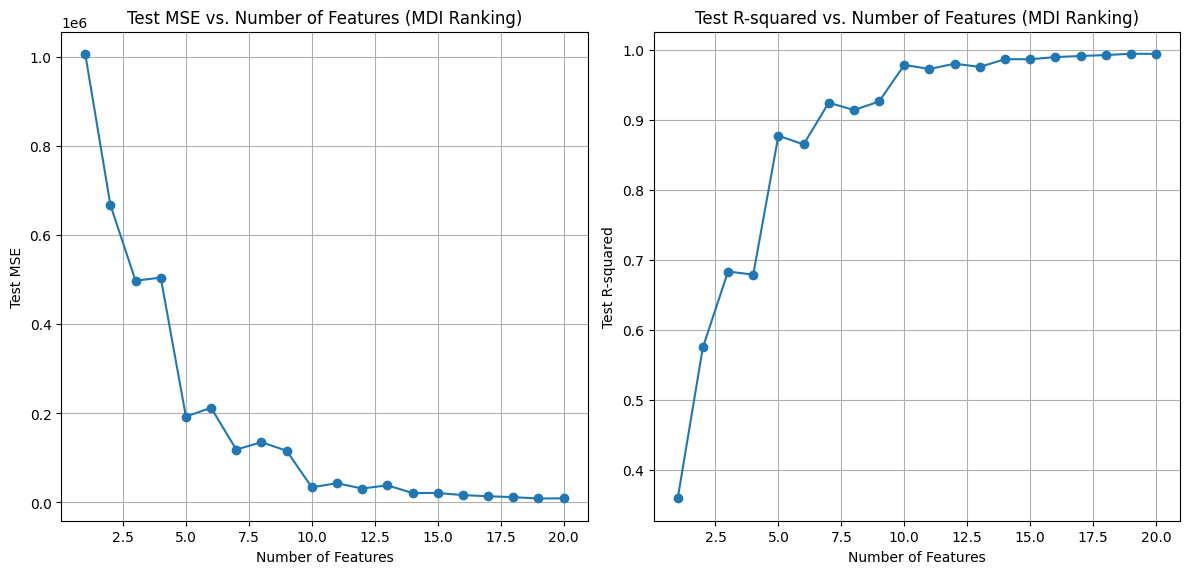


Test MSE for different numbers of features (MDI Ranking):
{1: 1006666.0787399989, 2: 667548.2168976254, 3: 497353.78379619913, 4: 504313.8128293337, 5: 192490.8410398186, 6: 212201.6464606908, 7: 118414.76648515544, 8: 135041.4302085653, 9: 115768.12957702926, 10: 33698.36765007889, 11: 42958.47180639352, 12: 30924.380140462144, 13: 38216.363850126785, 14: 20915.639397916533, 15: 21011.758281864204, 16: 16188.374940584285, 17: 13704.53807310092, 18: 11615.657328317853, 19: 8646.829628877038, 20: 8989.996858817725}

Test R-squared for different numbers of features (MDI Ranking):
{1: 0.3595286478759041, 2: 0.575285670080796, 3: 0.6835685068571189, 4: 0.6791403262520327, 5: 0.8775315153297035, 6: 0.8649909058207766, 7: 0.9246609504343944, 8: 0.9140825649884741, 9: 0.9263448207414686, 10: 0.9785600810943831, 11: 0.9726685232530499, 12: 0.9803249756990403, 13: 0.9756855955065127, 14: 0.9866928387390478, 15: 0.9866316850031002, 16: 0.9897004671103399, 17: 0.9912807591163683, 18: 0.992609768

In [16]:
from sklearn.base import clone 
from sklearn.pipeline import Pipeline
import warnings
from sklearn.exceptions import ConvergenceWarning

# Ignore all convergence warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)


feature_names = soybean_data_processed.drop(columns=[target_col]).columns.values # Array of feature names in 1D array
feature_importance_scores = feature_importance_score_cal(train_X_regr_standarised, train_y_regr, test_X_regr_standarised, test_y_regr, feature_names) 

sorted_indices = np.argsort(feature_importance_scores)[::-1]
ranked_feature_names = feature_names[sorted_indices]

# --- Train the best_mlp on all standardized training data ONCE ---
pipeline_all_features = Pipeline([
    ('scaler', StandardScaler()), # Fit on all training data below
    ('mlp', best_mlp)
])
pipeline_all_features.fit(train_X_regr, train_y_regr) # Fit on the original (non-standardized here, pipeline handles it)

# Make predictions using the best_mlp trained on all features
predictions_all = pipeline_all_features.predict(test_X_regr)
mse_all_features = mean_squared_error(test_y_regr, predictions_all)
r2_all_features = r2_score(test_y_regr, predictions_all)
print(f"\nPerformance of best_mlp on all features (for comparison):")
print(f"Test MSE (all features): {mse_all_features}")
print(f"Test R^2 (all features): {r2_all_features}")

mse_results = {}
r2_results = {}
max_features_to_test = min(20, len(feature_names))  # Test up to 20 features or all if less
n_features_to_test = range(1, max_features_to_test + 1)

for k in n_features_to_test:
    top_k_indices = sorted_indices[:k]
    selected_train_X = train_X_regr[:, top_k_indices]
    selected_test_X = test_X_regr[:, top_k_indices]

    
    # Full version of experiment commented out below (Look at markdown below for full result)
    '''
    # Preprocessing pipeline for selected features
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', best_mlp)
    ])

        # Train the model
    pipeline.fit(selected_train_X, train_y_regr)

        # Make predictions
    predictions = pipeline.predict(selected_test_X)

    '''

    #Quick version of pipeline so we don't face runtime issue 
    quick_mlp = clone(best_mlp)
    quick_mlp.set_params(max_iter=15, warm_start=False)

    quick_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', quick_mlp)
    ])

    # Train the model (quick version)
    quick_pipeline.fit(selected_train_X, train_y_regr)

    # Make predictions
    quick_predictions = quick_pipeline.predict(selected_test_X)

    # Evaluate performance
    mse = mean_squared_error(test_y_regr, quick_predictions)
    r2 = r2_score(test_y_regr, quick_predictions)

    mse_results[k] = mse
    r2_results[k] = r2

# Analyze and plot the results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(list(mse_results.keys()), list(mse_results.values()), marker='o')
plt.title('Test MSE vs. Number of Features (MDI Ranking)')
plt.xlabel('Number of Features')
plt.ylabel('Test MSE')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(list(r2_results.keys()), list(r2_results.values()), marker='o')
plt.title('Test R-squared vs. Number of Features (MDI Ranking)')
plt.xlabel('Number of Features')
plt.ylabel('Test R-squared')
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nTest MSE for different numbers of features (MDI Ranking):")
print(mse_results)
print("\nTest R-squared for different numbers of features (MDI Ranking):")
print(r2_results)
end = time.time()
print(f"\nTotal training time: {end - start:.2f} seconds")


OUTPUT:
Test MSE for different numbers of features (MDI Ranking):
{1: 998036.5680682149, 2: 162196.32888344768, 3: 24710.224168837132, 4: 6206.224866851984, 5: 4593.298164466848, 6: 1084.2412210663085, 7: 1019.289847275439, 8: 102.75125173394395, 9: 36.808440765208616, 10: 113.0900533726543, 11: 34.21335691839244, 12: 47.15823184937114, 13: 7.97866538177837, 14: 4.441476591027141, 15: 16.781016042609046, 16: 3.0271614982100146, 17: 2.6084592887606086, 18: 1.250541774205928, 19: 1.376017873175623, 20: 5.9696696512594745}

Test R-squared for different numbers of features (MDI Ranking):
{1: 0.34640218204157125, 2: 0.8937802781672792, 3: 0.9838176785152508, 4: 0.9959356448846506, 5: 0.9969919241903742, 6: 0.999289948165325, 7: 0.9993324837572476, 8: 0.9999327098865167, 9: 0.9999758947544245, 10: 0.9999259391744931, 11: 0.9999775942323735, 12: 0.999969116845593, 13: 0.9999947749025931, 14: 0.9999970913496546, 15: 0.9999890103871747, 16: 0.999998017561467, 17: 0.999998291762693, 18: 0.9999991810406542, 19: 0.9999990988684101, 20: 0.9999960905610247}

### 2.4 External Testing (3 Marks)
Develop a robust scikit-learn MLP model for soybean production prediction, and submit it along with your notebook and report. It will be run and evaluated on a test set containing soybean instances unseen by you. **Please note that the unseen dataset may contain noisy or missing features. Your model should be able to handle such cases.** Hint: you may want to experiment with model hyperparameters and data processing. You may find the sklearn module [pipeline](https://scikit-learn.org/stable/modules/compose.html#pipeline) useful when saving your completed model.

**Important: set your university username (e.g. mbxxabc3) below when saving your model.** Failure to do this correctly would lead to your model not being marked!

In [19]:
import sys
sys.path.append('src')
import model_eval_utils
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer

'''
Create a pipeline that handles missing values and applies feature selection (we will just use all features for best_mlp)
'''

def select_top_k(X, indices):
    return X[:, indices]

top_indices = sorted_indices # Choosing all features 
# Handle missing features / Standardise the data
preprocessing_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  
    ('scaler', StandardScaler()),
])
preprocessing_pipeline.fit(train_X_regr)

# Carry out feature selection, preprocess the data and select the already trained model 
final_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('feature_selector', FunctionTransformer(select_top_k, kw_args={'indices': top_indices})),
    ('mlp', best_mlp)
])

# Testing the pipeline on the new test set
# Define regression target and features
target_col = 'Seed Yield per Unit Area (SYUA)'
regression_targets = soybean_data_processed[target_col].to_numpy()
soybean_data = soybean_data_processed.drop(columns=[target_col])
regression_data = soybean_data.to_numpy()

new_train_X_regr, new_test_X_regr, new_train_y_regr, new_test_y_regr = sklearn.model_selection.train_test_split(
    regression_data,
    regression_targets,
    test_size=0.15,  
    random_state=None # Optionally remove or change random_state for a different split
)

final_pipeline.fit(new_train_X_regr, new_train_y_regr)

test_predictions_final_pipeline = final_pipeline.predict(new_test_X_regr)

test_mse_final_pipeline = mean_squared_error(new_test_y_regr, test_predictions_final_pipeline)

test_r2_final_pipeline = r2_score(new_test_y_regr, test_predictions_final_pipeline)

print("\nPerformance of the final pipeline on the testing set:")
print(f"Test MSE (final pipeline): {test_mse_final_pipeline}")
print(f"Test R^2 (final pipeline): {test_r2_final_pipeline}")

#### SAVE YOUR MODEL
student_username = "a38062an" # SET YOUR USERNAME HERE
model = final_pipeline
model_eval_utils.save_model(student_username, model)


Performance of the final pipeline on the testing set:
Test MSE (final pipeline): 7.076670629336028
Test R^2 (final pipeline): 0.9999954975099059


In [20]:
print(f"Total notebook run time: {time.time() - notebook_start_time:.0f} seconds")

Total notebook run time: 227 seconds


#### Option to test your saved model
Use the `run_model()` function to make sure your saved model can be loaded and run before submitting.

**Disclaimers:** Please note the score returned by `run_model()` is not in any way indicative of your final mark. This is just a simple test to make sure your model can be loaded and run, though there is no guarantee that your model will run on the unseen data just because it can be run here. When testing your model, the GTA will run your model following the practice below, but replacing the bunk_data with the unseen data.

In [21]:
# some random data from the training set
bunk_sample_indices = np.random.choice(train_X_regr.shape[0], size=3, replace=False)
# Extract the selected rows
bunk_sampled_X = train_X_regr[bunk_sample_indices]
bunk_sampled_y = train_y_regr[bunk_sample_indices]

score = model_eval_utils.run_model(student_username,
                                test_data=bunk_sampled_X,
                                test_labels=bunk_sampled_y,
                                model_folder=".")

Attempting to load from ....
Loaded ./a38062an.sav model.
Model score: 0.9999999693737986


### 2.5 Report (5 Marks)
1. Draw conclusions from your model selection results obtained in Section 2.2, based on factors like prediction accuracy, training efficiency, and model complexity. (*2 marks*)
2. Describe the design process of your selection and validation methods used in Section 2.3, and discuss your observations from your validation experiment. (*2 marks*)
3. Describe the methods you have used to address missing and noisy features in Section 2.4. (*1 mark*)